In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


case: original pulse


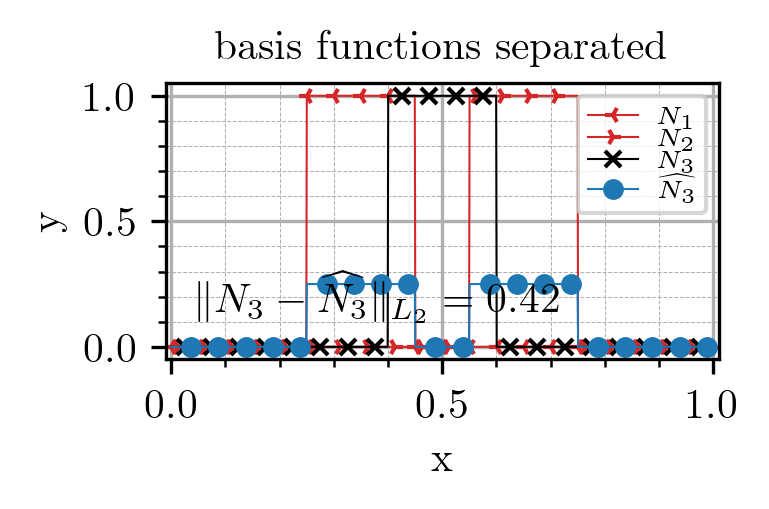

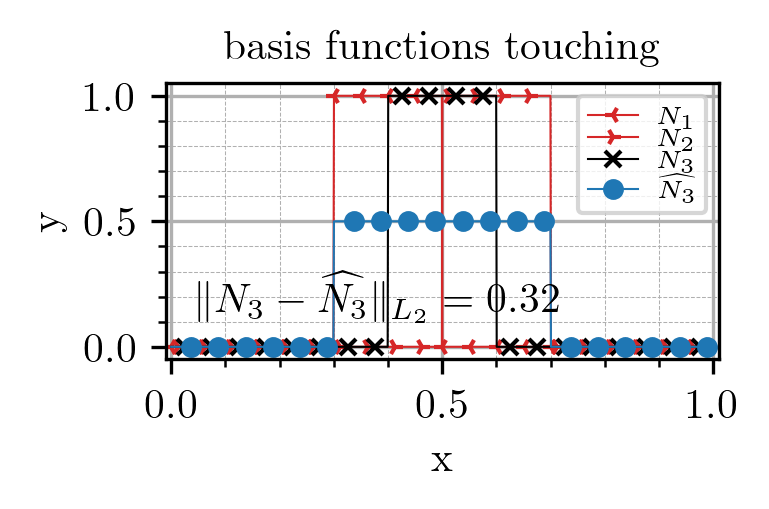

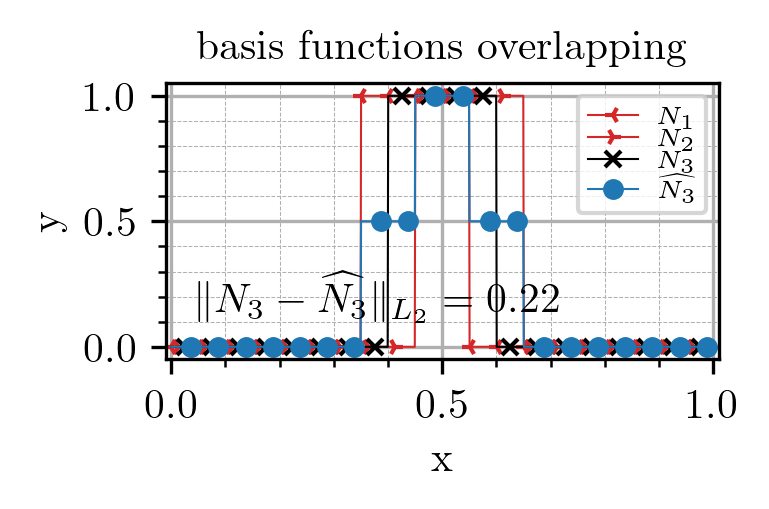

case: moving average smoothed


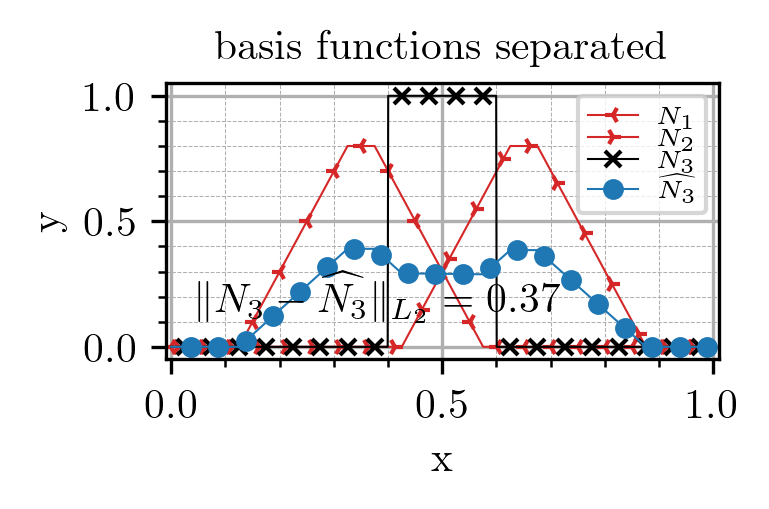

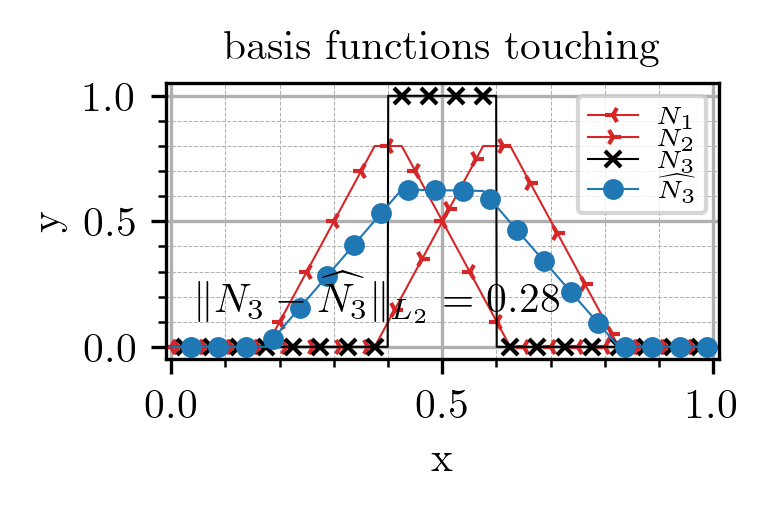

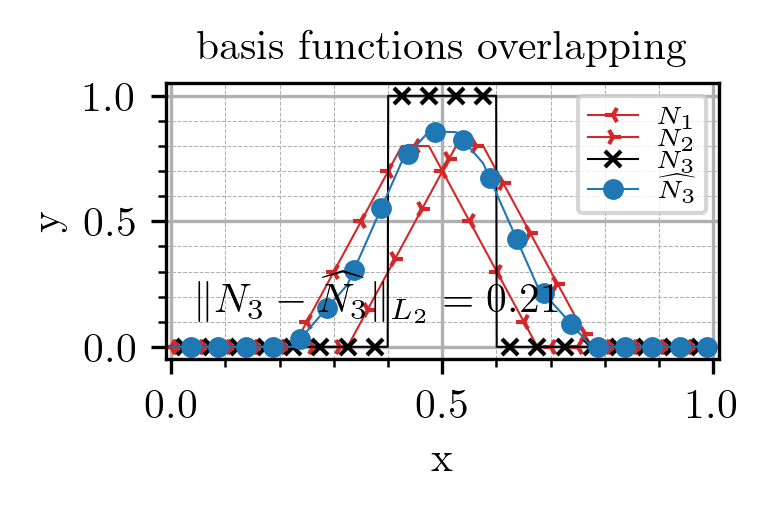

case: gaussian smoothed


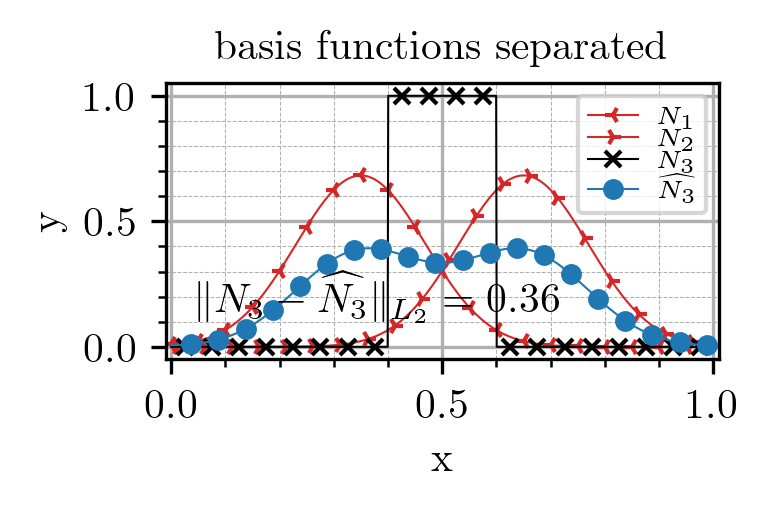

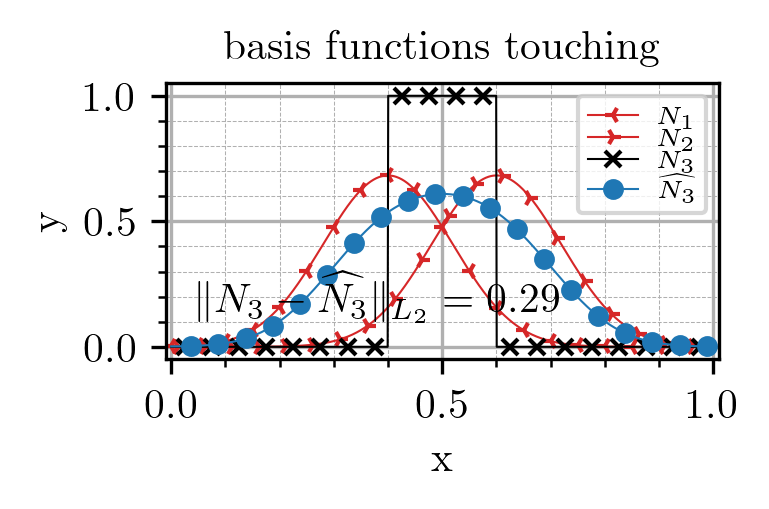

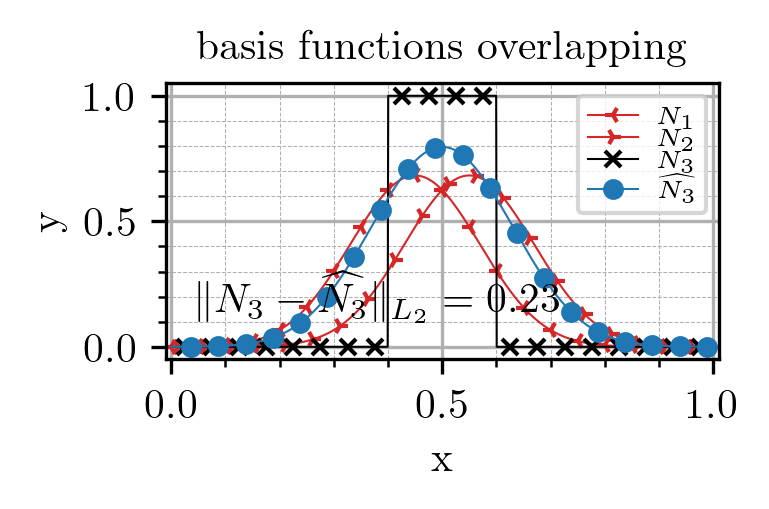

In [29]:
m = 1000
x = np.linspace(0, 1, m)

def f1(x, mu):
    # original
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(0.1+1e-6)] = 1
    return y


def f2(x, mu):
    # moving averagee
    y = f1(x, mu)
    k = np.ones((250,))/250
    return np.convolve(y, k, mode='same')


def f3(x, mu):
    # gaussian smoothing
    y = f1(x, mu)
    dx = 1/m
    return gaussian_filter1d(y, sigma=0.1/dx)



for name, f in zip(["original pulse", "moving average smoothed", "gaussian smoothed"], [f1, f2, f3]):
    print("case: "+name)
    for case, d in zip(["separated", "touching", "overlapping"], [0.15, 0.1, 0.05]):
        #print("basis functions "+case)
        N1 = f(x, 0.5-d)
        N2 = f(x, 0.5+d)
        N3 = f1(x, 0.5)

        A = np.vstack([N1, N2]).T
        coefficients, _, _, _ = np.linalg.lstsq(A, N3, rcond=None)
        a, b = coefficients

        N3_hat = a*N1 + b*N2


        markevery = 50
        fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
        plt.plot(x, N1, "C33-", lw=.5, ms=4, markevery=(0, markevery), label="$N_1$")
        plt.plot(x, N2, "C34-", lw=.5, ms=4, markevery=(int(0.25*markevery), markevery), label="$N_2$")
        plt.plot(x, N3, "kx-", lw=.5, ms=4, markevery=(int(0.50*markevery), markevery), label="$N_3$")
        plt.plot(x, N3_hat, "C0o-", lw=.5, ms=4, markevery=(int(.75*markevery), markevery), label="$\widehat{N_3}$")

        e = np.mean((N3_hat-N3)**2)**.5
        ax.text(0.05, 0.2, "$\|N_3-\widehat{N_3}\|_{L_2}"+"={:.2f}$".format(e), fontsize=10, va="center")

        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        plt.grid(True, which='minor', linestyle='--', lw=.25)
        plt.grid(True, which='major', linestyle='-')
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.xlim(-0.01, 1.01)
        plt.ylim(-0.05, 1.05)
        plt.title("basis functions "+case)
        plt.show()